In [17]:
# AlexNet : 이미지대회 우승모델, 모델공개 X, keras구현 X
import keras
from tensorflow.keras import layers, models
model = keras.Sequential()
model.add(keras.layers.Input(shape=(227,227,3)))
model.add(keras.layers.Conv2D(96, kernel_size=11, strides=4, activation='relu', padding='valid'))
model.add(keras.layers.MaxPooling2D(pool_size=3, strides=2))
model.add(keras.layers.Conv2D(256, kernel_size=5, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=3, strides=2))
model.add(keras.layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=3, strides=2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1000, activation='softmax'))

In [18]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_32 (Conv2D)          (None, 55, 55, 96)        34944     
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 27, 27, 96)        0         
 ng2D)                                                           
                                                                 
 conv2d_33 (Conv2D)          (None, 27, 27, 256)       614656    
                                                                 
 max_pooling2d_21 (MaxPooli  (None, 13, 13, 256)       0         
 ng2D)                                                           
                                                                 
 conv2d_34 (Conv2D)          (None, 13, 13, 384)       885120    
                                                                 
 conv2d_35 (Conv2D)          (None, 13, 13, 384)      

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

# 1. 데이터 로드 및 전처리
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 속도를 위해 데이터 일부만 사용 (실험용)
train_images, train_labels = train_images[:5000], train_labels[:5000]

# 이미지 크기를 227x227로 조정하는 함수 (AlexNet 규격)
def preprocess(image, label):
    image = tf.image.resize(image, (227, 227))
    image = image / 255.0  # 정규화
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(preprocess).batch(32)

# 2. AlexNet 모델 정의 (Sequential 방식)
model = models.Sequential([
    layers.Input(shape=(227, 227, 3)),
    
    # Layer 1
    layers.Conv2D(96, kernel_size=11, strides=4, activation='relu'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    
    # Layer 2
    layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    
    # Layer 3, 4, 5
    layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
    layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
    layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=3, strides=2),
    
    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax') # CIFAR-10은 클래스가 10개입니다
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. 학습 시작
# model.fit(train_ds, epochs=5)

데이터를 불러오는 중입니다...
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 32, 32, 64)        1792      
                                                                 
 max_pooling2d_17 (MaxPooli  (None, 16, 16, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_28 (Conv2D)          (None, 16, 16, 192)       110784    
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 8, 8, 192)         0         
 ng2D)                                                           
                                                                 
 conv2d_29 (Conv2D)          (None, 8, 8, 384)         663936    
                                                                 
 conv2d_30 (Conv2D)          (None, 

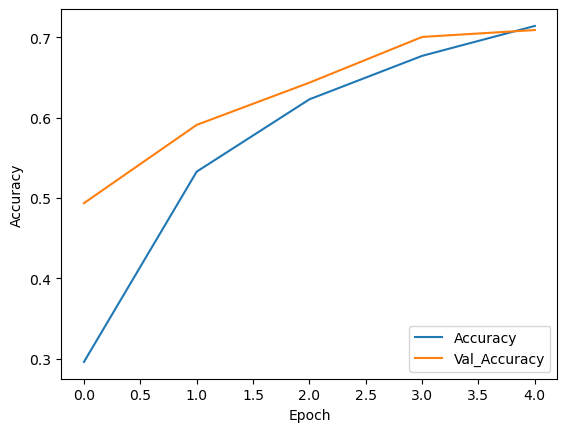

학습이 완료되었습니다!


In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

# 1. 데이터 로드 (CIFAR-10: 32x32 이미지 10종 세트)
print("데이터를 불러오는 중입니다...")
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 데이터 정규화 (0~255 사이의 값을 0~1 사이로 변환)
train_images, test_images = train_images / 255.0, test_images / 255.0

# 2. 모델 구성 (32x32에 최적화된 AlexNet 스타일)
model = models.Sequential([
    # 입력층: 32x32x3 (RGB 컬러 이미지)
    layers.Input(shape=(32, 32, 3)),
    
    # Conv 1: 필터 크기를 3으로 줄여서 정보 손실 방지
    layers.Conv2D(64, kernel_size=3, strides=1, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2, strides=2),
    
    # Conv 2
    layers.Conv2D(192, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2, strides=2),
    
    # Conv 3, 4, 5 (AlexNet의 특징적인 구조)
    layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2, strides=2),
    
    # Fully Connected (Dense): 요청하신 대로 512로 설정
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    
    # 출력층: CIFAR-10의 10개 클래스 분류
    layers.Dense(10, activation='softmax')
])

# 3. 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 요약 출력 (구조 확인용)
model.summary()

# 4. 학습 시작 (윈도우 CPU 사양을 고려해 epochs는 5회만 먼저 해보세요)
print("\n학습을 시작합니다. 잠시만 기다려주세요...")
history = model.fit(train_images, train_labels, epochs=5, 
                    validation_data=(test_images, test_labels),
                    batch_size=64)

# 5. 결과 시각화
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val_Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

print("학습이 완료되었습니다!")

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('cifar10-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, 
                    validation_data=(val_scaled, val_target),
                   callbacks=[checkpoint_cb, early_stopping_cb])